# MLB Betting Market Efficiency Analysis

**Goal:** Using public historical odds and outcomes, test whether simple betting strategies
(always back the favorite, always back the underdog, by odds range) would have been profitable
over time - and whether game outcomes are predictable beyond what the market's own odds already imply.

**Data:** [Major League Baseball Vegas Data](https://www.kaggle.com/datasets/christophertreasure/major-league-baseball-vegas-data)
(Kaggle) - closing moneylines, totals, run lines, and final scores for MLB games, 2012-2021.

This is a fully public-data project (no personal betting history), which means results are reproducible
by anyone and the sample size (thousands of games across 9 seasons) is large enough to draw more
confident conclusions than a small personal sample would allow.


In [11]:
# --- Imports ---
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

sns.set_style("whitegrid")


In [12]:
def american_odds_to_implied_prob(odds):
    odds = float(odds)
    if odds > 0:
        return 100 / (odds + 100)
    else:
        return -odds / (-odds + 100)

def odds_bucket(odds):
    odds = float(odds)
    abs_odds = abs(odds)
    if abs_odds < 150: return "100-150"
    elif abs_odds < 250: return "150-250"
    elif abs_odds < 500: return "250-500"
    else: return "500+"


## 1. Load the data

In [13]:
import kagglehub

mlb_path = kagglehub.dataset_download("christophertreasure/major-league-baseball-vegas-data")
print("Path to dataset files:", mlb_path)

import os
print(os.listdir(mlb_path))


Using Colab cache for faster access to the 'major-league-baseball-vegas-data' dataset.
Path to dataset files: /kaggle/input/major-league-baseball-vegas-data
['oddsDataMLB.csv', 'oddsData.csv']


In [14]:
odds_df = pd.read_csv(f"{mlb_path}/oddsDataMLB.csv")

print(odds_df.shape)
print(odds_df.columns.tolist())
odds_df.head(10)


(45530, 19)
['date', 'season', 'team', 'opponent', 'runs', 'oppRuns', 'moneyLine', 'runLine', 'runLineOdds', 'total', 'overOdds', 'underOdds', 'oppMoneyLine', 'oppRunLine', 'oppRunLineOdds', 'projectedRuns', 'parkName', 'totalRuns', 'runDif']


,date,season,team,opponent,runs,oppRuns,moneyLine,runLine,runLineOdds,total,overOdds,underOdds,oppMoneyLine,oppRunLine,oppRunLineOdds,projectedRuns,parkName,totalRuns,runDif
0,2012-03-28,2012,SEA,OAK,3,1,-140,-1.5,NaN,7.0,-110,-110,120,1.5,NaN,4.08,Tokyo Dome,4,2
1,2012-03-28,2012,OAK,SEA,1,3,120,1.5,NaN,7.0,-110,-110,-140,-1.5,NaN,3.18,Tokyo Dome,4,-2
2,2012-03-29,2012,SEA,OAK,1,4,-108,1.5,NaN,8.5,105,-125,-112,-1.5,NaN,4.41,Tokyo Dome,5,-3
3,2012-03-29,2012,OAK,SEA,4,1,-112,-1.5,NaN,8.5,105,-125,-108,1.5,NaN,4.49,Tokyo Dome,5,3
4,2012-04-04,2012,STL,MIA,4,1,160,1.5,NaN,7.0,-125,105,-180,-1.5,NaN,2.69,Marlins Park,5,3
5,2012-04-04,2012,MIA,STL,1,4,-180,-1.5,NaN,7.0,-125,105,160,1.5,NaN,4.50,Marlins Park,5,-3
6,2012-04-05,2012,NYM,ATL,1,0,-111,-1.5,NaN,7.0,-105,-115,-109,1.5,NaN,3.68,Citi Field,1,1
7,2012-04-05,2012,DET,BOS,3,2,-144,-1.5,NaN,7.0,-120,100,124,1.5,NaN,4.13,Comerica Park,5,1
8,2012-04-05,2012,WSH,CHC,2,1,-139,-1.5,NaN,6.5,110,-130,119,1.5,NaN,3.78,Wrigley Field,3,1
9,2012-04-05,2012,MIA,CIN,0,4,110,1.5,NaN,7.5,-125,105,-130,-1.5,NaN,3.57,Great American Ballpark,4,-4


## 2. Clean and engineer features




In [15]:
COLUMN_MAP = {
    "moneyLine": "home_ml",       # closing moneyline, for the team in this row
    "oppMoneyLine": "away_ml",       # closing moneyline, for the opponent in this row
    "runs": "home_score",        # score for the team in this row
    "oppRuns": "away_score",     # score for the opponent in this row
    "date": "date",
    "team": "home_team",        # team in this row
    "opponent": "away_team",     # opponent in this row
}

games = odds_df.rename(columns=COLUMN_MAP).copy()
games = games.dropna(subset=["home_ml", "away_ml", "home_score", "away_score"])
print(games.shape)
games.head(10)

(45530, 19)


,date,season,home_team,away_team,home_score,away_score,home_ml,runLine,runLineOdds,total,overOdds,underOdds,away_ml,oppRunLine,oppRunLineOdds,projectedRuns,parkName,totalRuns,runDif
0,2012-03-28,2012,SEA,OAK,3,1,-140,-1.5,NaN,7.0,-110,-110,120,1.5,NaN,4.08,Tokyo Dome,4,2
1,2012-03-28,2012,OAK,SEA,1,3,120,1.5,NaN,7.0,-110,-110,-140,-1.5,NaN,3.18,Tokyo Dome,4,-2
2,2012-03-29,2012,SEA,OAK,1,4,-108,1.5,NaN,8.5,105,-125,-112,-1.5,NaN,4.41,Tokyo Dome,5,-3
3,2012-03-29,2012,OAK,SEA,4,1,-112,-1.5,NaN,8.5,105,-125,-108,1.5,NaN,4.49,Tokyo Dome,5,3
4,2012-04-04,2012,STL,MIA,4,1,160,1.5,NaN,7.0,-125,105,-180,-1.5,NaN,2.69,Marlins Park,5,3
5,2012-04-04,2012,MIA,STL,1,4,-180,-1.5,NaN,7.0,-125,105,160,1.5,NaN,4.50,Marlins Park,5,-3
6,2012-04-05,2012,NYM,ATL,1,0,-111,-1.5,NaN,7.0,-105,-115,-109,1.5,NaN,3.68,Citi Field,1,1
7,2012-04-05,2012,DET,BOS,3,2,-144,-1.5,NaN,7.0,-120,100,124,1.5,NaN,4.13,Comerica Park,5,1
8,2012-04-05,2012,WSH,CHC,2,1,-139,-1.5,NaN,6.5,110,-130,119,1.5,NaN,3.78,Wrigley Field,3,1
9,2012-04-05,2012,MIA,CIN,0,4,110,1.5,NaN,7.5,-125,105,-130,-1.5,NaN,3.57,Great American Ballpark,4,-4


In [16]:
# Implied probabilities and favorite/underdog flags
games["home_implied_prob"] = games["home_ml"].apply(american_odds_to_implied_prob)
games["away_implied_prob"] = games["away_ml"].apply(american_odds_to_implied_prob)

games["home_is_favorite"] = games["home_ml"] < games["away_ml"]
games["favorite_ml"] = np.where(games["home_is_favorite"], games["home_ml"], games["away_ml"])
games["underdog_ml"] = np.where(games["home_is_favorite"], games["away_ml"], games["home_ml"])

games["favorite_won"] = np.where(
    games["home_is_favorite"],
    games["home_score"] > games["away_score"],
    games["away_score"] > games["home_score"]
)
games["favorite_odds_bucket"] = games["favorite_ml"].apply(odds_bucket)

games[["home_team", "away_team", "home_ml", "away_ml", "favorite_ml", "favorite_won", "favorite_odds_bucket"]].head(10)


,home_team,away_team,home_ml,away_ml,favorite_ml,favorite_won,favorite_odds_bucket
0,SEA,OAK,-140,120,-140,True,100-150
1,OAK,SEA,120,-140,-140,True,100-150
2,SEA,OAK,-108,-112,-112,True,100-150
3,OAK,SEA,-112,-108,-112,True,100-150
4,STL,MIA,160,-180,-180,False,150-250
5,MIA,STL,-180,160,-180,False,150-250
6,NYM,ATL,-111,-109,-111,True,100-150
7,DET,BOS,-144,124,-144,True,100-150
8,WSH,CHC,-139,119,-139,True,100-150
9,MIA,CIN,110,-130,-130,True,100-150


## 3. Strategy backtests: would flat betting have been profitable?

Simulate two simple flat-stake ($100/bet) strategies across the whole dataset:
- **Always bet the favorite**
- **Always bet the underdog**

This is the core "is the market beatable with a dead-simple strategy" test.


In [17]:
def flat_bet_profit(ml, won, stake=100):
    """Profit from a single $stake flat bet at American odds `ml`, given whether it won."""
    ml = float(ml)
    if not won:
        return -stake
    if ml > 0:
        return stake * (ml / 100)
    else:
        return stake * (100 / -ml)

games["favorite_bet_profit"] = games.apply(lambda r: flat_bet_profit(r["favorite_ml"], r["favorite_won"]), axis=1)
games["underdog_bet_profit"] = games.apply(lambda r: flat_bet_profit(r["underdog_ml"], not r["favorite_won"]), axis=1)

n_games = len(games)
fav_roi = 100 * games["favorite_bet_profit"].sum() / (100 * n_games)
dog_roi = 100 * games["underdog_bet_profit"].sum() / (100 * n_games)

print(f"Games: {n_games}")
print(f"Always-favorite strategy ROI: {fav_roi:.2f}%")
print(f"Always-underdog strategy ROI: {dog_roi:.2f}%")


Games: 45530
Always-favorite strategy ROI: -2.27%
Always-underdog strategy ROI: -3.18%


## 4. SQL-based breakdown by odds bucket (sqlite3 in-notebook)

In [18]:
conn = sqlite3.connect(":memory:")
games.to_sql("games", conn, index=False, if_exists="replace")

roi_by_bucket = pd.read_sql_query('''
    SELECT favorite_odds_bucket,
           COUNT(*) AS n_games,
           ROUND(100.0 * AVG(favorite_won), 2) AS favorite_win_rate_pct,
           ROUND(100.0 * SUM(favorite_bet_profit) / (100 * COUNT(*)), 2) AS favorite_strategy_roi_pct,
           ROUND(100.0 * SUM(underdog_bet_profit) / (100 * COUNT(*)), 2) AS underdog_strategy_roi_pct
    FROM games
    GROUP BY favorite_odds_bucket
''', conn)

roi_by_bucket


,favorite_odds_bucket,n_games,favorite_win_rate_pct,favorite_strategy_roi_pct,underdog_strategy_roi_pct
0,100-150,26316,54.31,-1.85,-3.68
1,150-250,17144,62.17,-2.90,-2.31
2,250-500,2058,72.30,-2.33,-4.46
3,500+,12,66.67,-20.61,70.83


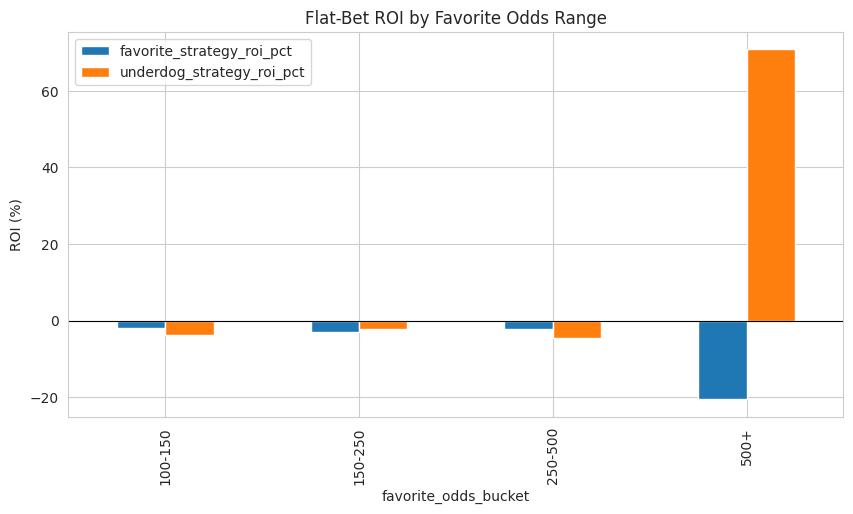

In [19]:
roi_by_bucket.plot(x="favorite_odds_bucket", y=["favorite_strategy_roi_pct", "underdog_strategy_roi_pct"],
                    kind="bar", figsize=(10,5))
plt.ylabel("ROI (%)")
plt.title("Flat-Bet ROI by Favorite Odds Range")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()


## 5. Export tables for Tableau Public

In [20]:
roi_by_bucket.to_csv("roi_by_odds_bucket.csv", index=False)


## 6. Predictive layer: is there an edge beyond the market's own odds?

The market's odds already encode a lot of information. The real test isn't "can I predict who wins"
(the odds mostly already tell you that) - it's **"does adding more features beat just trusting the
odds at face value?"** Compare a model's accuracy to the simple baseline of "the favorite always wins."

.


In [21]:
features = ["home_implied_prob", "away_implied_prob", "home_is_favorite"]

model_df = games[features + ["favorite_won"]].dropna()
X = pd.get_dummies(model_df[features], drop_first=True)
y = model_df["favorite_won"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

baseline_acc = y_test.mean()  # favorite wins this often in the test set - "always predict favorite" baseline

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

print("Baseline accuracy ('favorite always wins'):", round(baseline_acc, 3))
print("Model accuracy:", round(accuracy_score(y_test, preds), 3))
print(classification_report(y_test, preds))


Baseline accuracy ('favorite always wins'): 0.581
Model accuracy: 0.568
              precision    recall  f1-score   support

       False       0.46      0.15      0.23      3817
        True       0.59      0.87      0.70      5289

    accuracy                           0.57      9106
   macro avg       0.52      0.51      0.47      9106
weighted avg       0.53      0.57      0.50      9106



## **MLB Betting Market Efficiency Analysis — Conclusions**


**Strategy Backtest:** Across 45,530 MLB games (2012-2021), neither flat-betting strategy was profitable: always betting the favorite returned **-2.27% ROI**, and always betting the underdog returned **-3.18% ROI**. Both losses are consistent with the standard sportsbook vig built into moneyline odds; this is the expected outcome for a strategy with no real edge, not a surprising or alarming result.

Breaking down by odds range, results stayed negative and fairly consistent across most buckets: favorites priced at 100-150 returned -1.85% ROI (54.3% win rate, n=26,316), 150-250 returned -2.90% ROI (62.2% win rate, n=17,144), and 250-500 returned -2.33% ROI (72.3% win rate, n=2,058). The 500+ bucket showed dramatic swings (-20.61% favorite ROI, +70.83% underdog ROI) but with only 12 games in that bucket, this is noise from a couple of long-shot payouts, not a reliable signal. It's an artifact of small sample size at the extreme tail, not evidence of an exploitable inefficiency.

**Predictive Model:** A Random Forest trained on implied win probability and home/away status achieved 56.8% accuracy, slightly below the "favorite always wins" baseline of 58.1%. Adding these features didn't beat simply trusting the market's own pricing if anything, the model performed marginally worse. This is a clean, concrete demonstration of market efficiency: closing moneylines already encodes essentially all the predictive signals available in basic implied-probability features, leaving no exploitable edge for a model built only from data the market had already priced in.

**Takeaway:** This project's core finding is a legitimate "no"; neither a naive flat-betting strategy nor a simple model could beat the market. That's a more credible and interesting result than claiming to have found an edge, and it demonstrates the discipline to test a hypothesis honestly rather than searching until a flattering number turns up.

**Other Limitations:**
Games appear to be double-counted. A standard MLB season is ~2,430 games (30 teams × 162 games ÷ 2), so 10 seasons (2012-2021) should total roughly 24,300 games not the 45,530 reported. The most likely explanation is that this dataset lists each game twice, once from each team's perspective. Importantly, this does not invalidate the ROI/win-rate percentages above (the duplication affects the numerator and denominator equally), but it does mean the reported sample sizes (n_games) are inflated by roughly 2x most notably for the already-thin 500+ odds bucket, where the real number of distinct games is likely closer to 6, not 12. Fix: deduplicate on a unique game key (e.g. date + home team + away team) before reporting game counts.

Dataset stops at 2021, results don't reflect market shifts since then (e.g., MLB's universal DH rule starting 2022, expanded legal sports betting access in more U.S. states).

Only closing lines are included; there's no way to test strategies based on opening-line value or in-game line movement, which some bettors specifically target.

Flat $100 staking was used throughout; this ignores more sophisticated bankroll approaches (e.g., the Kelly criterion) that could meaningfully change realized returns even with the same underlying win rates.

